# The Charge Solver in tidy3d

This picks up right after `tidy3d_101.ipynb`, so tidy3d should already be installed and your API key already set up.

Here we'll look at tidy3d's **Charge solver** — it simulates how charge moves around inside a semiconductor device. It uses the same `Scene`/`Structure` building blocks as the FDTD solver you already know, just pointed at different physics. We'll build one complete example together: a silicon PN junction diode, the same kind of junction that's at the heart of almost every transistor and chip.

## What does it actually solve?

Picture a doped piece of silicon with a voltage applied across it. Electrons and holes inside start moving: some get pushed by the electric field (drift), some just wander from where they're crowded to where they're not (diffusion). The Charge solver figures out where every electron and hole ends up once things settle down, at a fixed voltage and a fixed temperature.

Under the hood, that means solving Poisson's equation (which relates charge to electric potential) together with continuity equations for electrons and holes; you don't need to touch any of that math directly. You build the device the same way you'd build an FDTD simulation, just with `HeatChargeSimulation` instead of `Simulation`, and it runs on the cloud the same way too, through `web.run`.

## What can you build with it?

- Diodes and transistors — PN junctions, MOSFETs.
- Simple electrical components — resistors, capacitors.
- Doped photonic devices, where this solver hands off to tidy3d's optical or thermal solvers — think electro-optic modulators or thermo-optic switches.

We're keeping it simple here: just a standalone PN diode, no optics or heat involved.

## What we'll do, step by step

1. Define the device geometry and its doping profile.
2. Define the semiconductor material properties.
3. Define contacts, as voltage boundary conditions.
4. Define the mesh.
5. Visualise the setup.
6. Estimate the simulation cost.
7. Run the simulation.
8. Visualise the results: the I-V curve, the potential, and the carrier concentrations.

## Our device: a silicon PN diode

Take a bar of silicon. Dope the left half p-type, the right half n-type, so they meet at a sharp junction right at `x = 0`. That's the whole device.

One quirk: the Charge solver needs every structure to have some thickness on all three axes, so we give it a thin `z` dimension even though nothing physically interesting happens along that direction — it's not meant to represent a real thickness, just to keep the solver happy.

We'll cap each end with a metal contact, then sweep the voltage on one contact while holding the other at ground. That single sweep gives us the whole I-V curve in one run.

One more thing: every number below (doping, mesh size, voltage steps) is picked to make this run fast and cheap, not to model a real, production-grade diode.

In [24]:
import numpy as np
import matplotlib.pyplot as plt

import tidy3d as td
import tidy3d.web as web

print("Tidy3D version:", td.__version__)

Tidy3D version: 2.11.2


### 1. Geometry and doping

The diode body itself is just one solid rectangular block — we don't split it into a "p piece" and an "n piece." Instead, we use a single `SemiconductorMedium` for the whole thing, and paint doping onto it with two separate `ConstantDoping` regions: one says "acceptors live here" (p-type, left half), the other says "donors live here" (n-type, right half).

In [2]:
# All dimensions in microns, all concentrations in cm^-3

x_half_width = 1.0     # half-width of the diode body
y_height = 0.5           # height of the diode body
z_thickness = 0.1        # thickness; kept thin and otherwise arbitrary
device_width = 2 * x_half_width

contact_width = 0.1     # width of the metal contact pad at each end

# Domain clearance beyond the contacts, so no structure edge sits exactly on the
# simulation boundary. The voltage boundary conditions are attached to the contacts'
# own surfaces below, not to the domain edge, so the contacts don't need to reach it.
x_margin = 0.1
sim_width = device_width + 2 * x_margin

doping_concentration = 1e17   # acceptor / donor concentration, both sides

print("Device width [um]:", device_width)
print("Doping concentration [cm^-3]:", doping_concentration)

Device width [um]: 2.0
Doping concentration [cm^-3]: 1e+17


In [3]:
# Acceptor doping on the left half (p-type), donor doping on the right half (n-type).
# Each ConstantDoping box is additive on top of the SemiconductorMedium it's attached to.
acceptors = td.ConstantDoping(
    center=(-x_half_width / 2, 0, 0),
    size=(x_half_width, y_height, td.inf),
    concentration=doping_concentration,
)

donors = td.ConstantDoping(
    center=(x_half_width / 2, 0, 0),
    size=(x_half_width, y_height, td.inf),
    concentration=doping_concentration,
)

### 2. Material properties

To describe silicon as a semiconductor, the solver needs a handful of numbers: permittivity, how many available electron/hole states sit in each energy band, the bandgap, how mobile each carrier is, and at least one way for electrons and holes to recombine.

We keep every one of these as simple as possible: constant mobility and a single recombination mechanism. Real fab-grade models add more effects, like bandgap narrowing or Auger/radiative recombination, but those matter most at the very high doping levels used in real chips; at the moderate doping we're using here, they'd barely move the needle.

In [4]:
silicon = td.SemiconductorMedium(
    permittivity=11.7,
    N_c=td.ConstantEffectiveDOS(N=2.86e19),
    N_v=td.ConstantEffectiveDOS(N=3.1e19),
    E_g=td.ConstantEnergyBandGap(eg=1.11),
    mobility_n=td.ConstantMobilityModel(mu=1400),
    mobility_p=td.ConstantMobilityModel(mu=450),
    R=[td.ShockleyReedHallRecombination(tau_n=1e-6, tau_p=1e-6)],
    N_a=[acceptors],
    N_d=[donors],
    name="silicon_pn",
)

### Contacts and the diode body

We give the diode body an infinite size (`td.inf`) on every axis. That's a shortcut: rather than sizing it to exactly match the simulation domain, we just let it fill the whole thing, so there's no risk of a gap at the edges.

The two metal contacts work the same way, except only in `x` do we give them a real size — they're infinite in `y` and `z`, so they span the full height and thickness of the device automatically. Since we list them *after* the diode body, tidy3d lets them win wherever they overlap it — which is exactly how you'd cut a metal contact into each end of a real device.

The voltage boundary conditions (below) attach to the contacts' own surfaces, not to the edge of the simulation domain. That's why the contacts don't need to reach all the way to the domain boundary — and why we added a bit of `x_margin` earlier, just so nothing sits awkwardly flush with the domain edge.

In [5]:
diode_body = td.Structure(
    geometry=td.Box(center=(0, 0, 0), size=(td.inf, td.inf, td.inf)),
    medium=silicon,
    name="diode_body",
)

contact_medium = td.ChargeConductorMedium(conductivity=1)

contact_p = td.Structure(
    geometry=td.Box(
        center=(-x_half_width + contact_width / 2, 0, 0),
        size=(contact_width, td.inf, td.inf),
    ),
    medium=contact_medium,
    name="contact_p",
)

contact_n = td.Structure(
    geometry=td.Box(
        center=(x_half_width - contact_width / 2, 0, 0),
        size=(contact_width, td.inf, td.inf),
    ),
    medium=contact_medium,
    name="contact_n",
)

structures = [diode_body, contact_p, contact_n]

### Let's look at the doping

A `Scene` is just a lightweight bundle of structures for visualising the same job as FDTD. Calling `plot_structures_property` with `property="doping"` plots the net doping, `N_d - N_a`: positive on the n-side, negative on the p-side, with a clean step right where they meet. This is the one plot in the whole notebook that actually shows you where the junction is: the geometry plots later on won't.

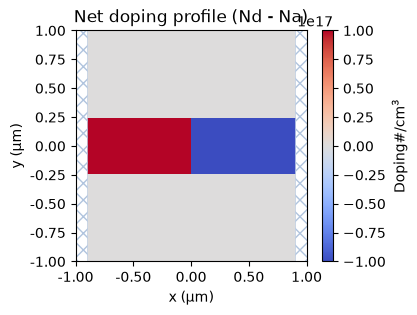

In [6]:
air = td.Medium()
scene = td.Scene(structures=structures, medium=air)

fig, ax = plt.subplots(figsize=(8, 3))
scene.plot_structures_property(z=0, property="doping", ax=ax)
ax.set_title("Net doping profile (Nd - Na)")
plt.show()

### 3. Setting the voltage

Boundary conditions attach to a specific structure's surface using `td.StructureBoundary` — here, the two contacts. We sweep the p-side contact through a list of voltages, from reverse bias to forward bias, and just hold the n-side at 0 V, grounded.

That's enough to get the whole I-V curve in a single run. Every voltage you see plotted later is really "p-side minus grounded n-side," so positive numbers mean forward bias.

In [7]:
bias_voltages = list(np.linspace(-1.0, 0.7, 18))

bc_p = td.HeatChargeBoundarySpec(
    condition=td.VoltageBC(source=td.DCVoltageSource(voltage=bias_voltages)),
    placement=td.StructureBoundary(structure=contact_p.name),
)

bc_n = td.HeatChargeBoundarySpec(
    condition=td.VoltageBC(source=td.DCVoltageSource(voltage=0)),
    placement=td.StructureBoundary(structure=contact_n.name),
)

boundary_spec = [bc_p, bc_n]

print("Bias voltages [V]:", bias_voltages[0], "to", bias_voltages[-1])

Bias voltages [V]: -1.0 to 0.7


### 4. The mesh, and what kind of physics to solve

`UniformUnstructuredGrid` is the simplest mesh you can ask for: pick one cell size, `dl`, and tidy3d fits a mesh around your structures automatically. A finer mesh would capture the depletion region near the junction more precisely; here we're trading some of that accuracy for a fast, cheap run.

`analysis_spec` tells the solver what kind of problem to solve. `IsothermalSteadyChargeDCAnalysis` means: fixed temperature, steady state, DC voltage — currently the only mode the Charge solver offers.

Two things make this particular problem hard on the solver: the doping jumps abruptly at the junction, and we're sweeping all the way into forward conduction, where the current changes by many orders of magnitude over less than a volt. If the solver tried to jump straight from one voltage to the next, it would likely fail to converge. `convergence_dv` fixes that by having it ramp up in small internal steps between each voltage point instead. Think of it as the solver taking the stairs instead of trying to jump straight to the top floor.

In [8]:
grid_spec = td.UniformUnstructuredGrid(dl=0.01)

# abs_tol should sit well below the carrier concentrations actually present in the
# device (Flexcompute's own examples pick abs_tol several orders of magnitude below
# their doping level, e.g. ~1e16 against ~1e20 cm^-3 carriers). Our doping is 1e17,
# so abs_tol is scaled down to match, rather than reused as-is from a device with a
# very different carrier scale.
convergence_settings = td.ChargeToleranceSpec(
    rel_tol=1e-4,
    abs_tol=1e8,
    max_iters=400,
    ramp_up_iters=5,
)

analysis_spec = td.IsothermalSteadyChargeDCAnalysis(
    temperature=300,
    convergence_dv=0.1,
    tolerance_settings=convergence_settings,
)

### Monitors

You actually don't need a monitor to get the I-V curve because every DC isothermal run reports that automatically. We add two monitors anyway, just so we can look inside the device: one for the electrostatic potential, one for the free electron and hole concentrations.

Both are sized to cover only the silicon, not the two metal contacts. That's deliberate: the contacts are `ChargeConductorMedium`, not `SemiconductorMedium`. If the monitor region reached into the contacts, you'd get `-inf`/`NaN` values right at the metal-silicon interface — which is exactly what causes those ugly, spiky lines you sometimes see in mesh plots.

In [9]:
# Width covering only the semiconductor, excluding the contact pads at each end
monitor_width = device_width - 2 * contact_width

potential_monitor = td.SteadyPotentialMonitor(
    center=(0, 0, 0),
    size=(monitor_width, y_height, 0),
    name="potential",
    unstructured=True,
)

carrier_monitor = td.SteadyFreeCarrierMonitor(
    center=(0, 0, 0),
    size=(monitor_width, y_height, 0),
    name="carriers",
    unstructured=True,
)

### 5. Putting it all together

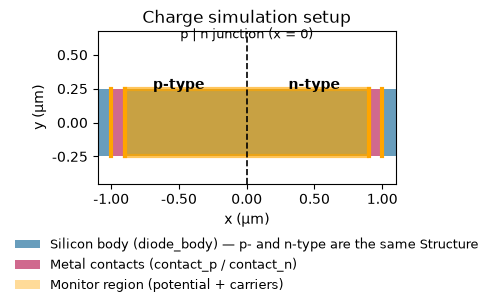

In [23]:
charge_sim = td.HeatChargeSimulation(
    center=(0, 0, 0),
    size=(sim_width, y_height, z_thickness),
    structures=structures,
    medium=air,
    boundary_spec=boundary_spec,
    grid_spec=grid_spec,
    analysis_spec=analysis_spec,
    monitors=[potential_monitor, carrier_monitor],
)

from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(8, 3.5))
charge_sim.plot(z=0, ax=ax)

# plot() colors patches by structure/monitor list order but draws no legend; read the
# actual rendered colors back off the patches so the swatches below match exactly.
silicon_color = ax.patches[0].get_facecolor()
contact_color = ax.patches[1].get_facecolor()
monitor_color = ax.patches[len(structures)].get_facecolor()

# The p/n split isn't visible above: both halves are the same diode_body Structure
# and medium, so it's annotated manually here from the known geometry instead.
ax.set_ylim(-y_height * 0.9, y_height * 1.35)
ax.axvline(0, color="black", linestyle="--", linewidth=1.2)
ax.text(0, y_height * 1.2, "p | n junction (x = 0)", ha="center", va="bottom", fontsize=9)
ax.text(-x_half_width / 2, y_height * 0.55, "p-type", ha="center", va="center", fontsize=10, weight="bold")
ax.text(x_half_width / 2, y_height * 0.55, "n-type", ha="center", va="center", fontsize=10, weight="bold")

legend_handles = [
    Patch(facecolor=silicon_color, label="Silicon body (diode_body) — p- and n-type are the same Structure"),
    Patch(facecolor=contact_color, label="Metal contacts (contact_p / contact_n)"),
    Patch(facecolor=monitor_color, label="Monitor region (potential + carriers)"),
]
ax.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.28), frameon=False, fontsize=9)

ax.set_title("Charge simulation setup")
plt.tight_layout()
plt.show()

### 6. Checking the cost before you run it

Same as with FDTD: uploading a task and asking for a cost estimate doesn't run anything and doesn't spend any FlexCredits. `web.estimate_cost` gives you the worst case — what it would cost if the solver needed every single allocated iteration to converge. In practice it usually converges sooner, so the real cost (checked after running) tends to be lower.

In [11]:
cost_check_job = web.Job(
    simulation=charge_sim,
    task_name="charge_pn_diode_cost_check",
    verbose=True,
)

estimated_cost = web.estimate_cost(cost_check_job.task_id)

print("Estimated maximum cost [FlexCredits]:", estimated_cost)

16:48:46 CST Created task 'charge_pn_diode_cost_check' with resource_id         
             'hec-7f681f48-2ce7-4378-bab7-f502811ae9b3' and task_type           
             'HEAT_CHARGE'.

             Tidy3D's HeatCharge solver is currently in the beta stage. Cost of 
             HeatCharge simulations is subject to change in the future.

Output()

16:48:51 CST Estimated FlexCredit cost: 0.025. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

Estimated maximum cost [FlexCredits]: 0.025


### 7. Running it for real

If the estimated cost looks fine, we don't need to re-upload anything — the same task from the cost check can just be run directly with `web.run`.

In [ ]:
charge_data = web.run(
    charge_sim,
    task_name="charge_pn_diode",
    path="data/charge_pn_diode.hdf5",
)

In [14]:
from tidy3d import web

charge_data = web.load(
    task_id="hec-6905a1c7-c382-49c4-80d6-816ab4dfb759",
    path="data/charge_pn_diode.hdf5",
)

Output()

12:51:43 CST Loading results from data/charge_pn_diode.hdf5

### 8. The I-V curve

Every Charge simulation reports the current at each swept voltage automatically, in `device_characteristics.steady_dc_current_voltage` — no monitor needed. The number comes out in amps for the thin `z_thickness` slab we built; make the slab thicker, and the current scales up linearly with it.

On a log scale, you should see the classic diode signature: current climbing exponentially under forward bias, and staying pinned near zero under reverse bias.

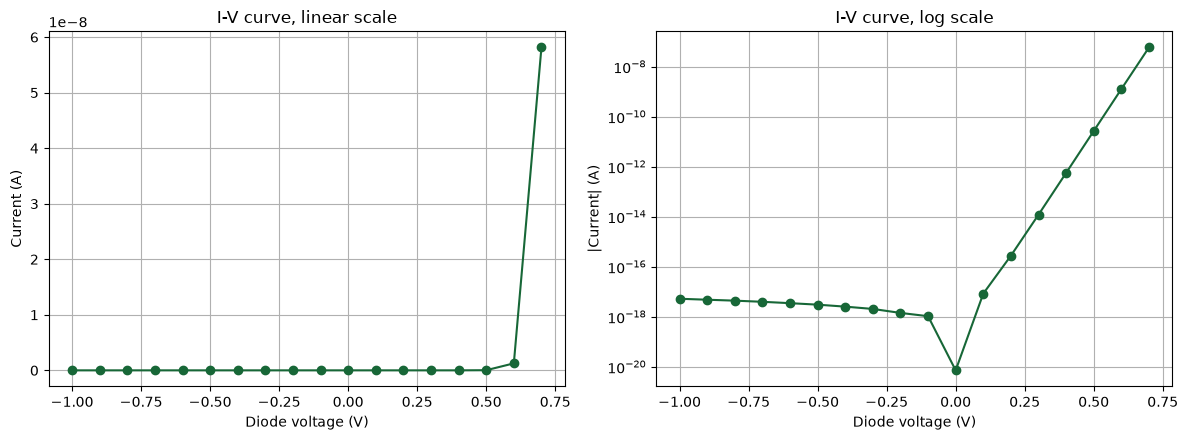

In [15]:
iv = charge_data.device_characteristics.steady_dc_current_voltage
voltages_result = iv["v"].as_numpy()
currents = iv.values

fig, (ax_lin, ax_log) = plt.subplots(1, 2, figsize=(12, 4.5))

ax_lin.plot(voltages_result, currents, marker="o")
ax_lin.set_xlabel("Diode voltage (V)")
ax_lin.set_ylabel("Current (A)")
ax_lin.set_title("I-V curve, linear scale")
ax_lin.grid(True)

ax_log.semilogy(voltages_result, np.abs(currents), marker="o")
ax_log.set_xlabel("Diode voltage (V)")
ax_log.set_ylabel("|Current| (A)")
ax_log.set_title("I-V curve, log scale")
ax_log.grid(True, which="both")

plt.tight_layout()
plt.show()

Here's the same data as a plain table, so you can check the raw numbers yourself. For a diode this size and doping, expect the current to stay tiny and roughly flat through reverse bias and the first bit of forward bias, then shoot up over the last ~0.2-0.3 V as the diode really turns on. A jump of many orders of magnitude across the sweep isn't a bug — it's the entire point of the log-scale plot above.

In [16]:
print(f"{'Voltage (V)':>12} | {'Current (A)':>14}")
print("-" * 29)
for v, i in zip(voltages_result, currents):
    print(f"{v:12.3f} | {i:14.3e}")

 Voltage (V) |    Current (A)
-----------------------------
      -1.000 |     -5.236e-18
      -0.900 |     -4.788e-18
      -0.800 |     -4.395e-18
      -0.700 |     -3.958e-18
      -0.600 |     -3.487e-18
      -0.500 |     -3.041e-18
      -0.400 |     -2.534e-18
      -0.300 |     -2.050e-18
      -0.200 |     -1.421e-18
      -0.100 |     -1.052e-18
       0.000 |     -7.189e-21
       0.100 |      8.414e-18
       0.200 |      2.757e-16
       0.300 |      1.202e-14
       0.400 |      5.623e-13
       0.500 |      2.662e-11
       0.600 |      1.260e-09
       0.700 |      5.813e-08


### Potential and carrier concentration

Let's look inside the device at three points: reverse bias, near-zero, and forward bias. Watch the depletion region — the narrow zone near the junction where electron concentration drops off sharply. It should widen under reverse bias and narrow under forward bias.

Both monitors used `unstructured=True`, so the data comes back on tidy3d's native triangular mesh, not a regular grid. Rather than plot that mesh directly, `.interp()` resamples each slice onto a plain rectangular grid first — after that it's just an ordinary array, and plots with normal matplotlib/xarray, no special mesh-plotting needed.

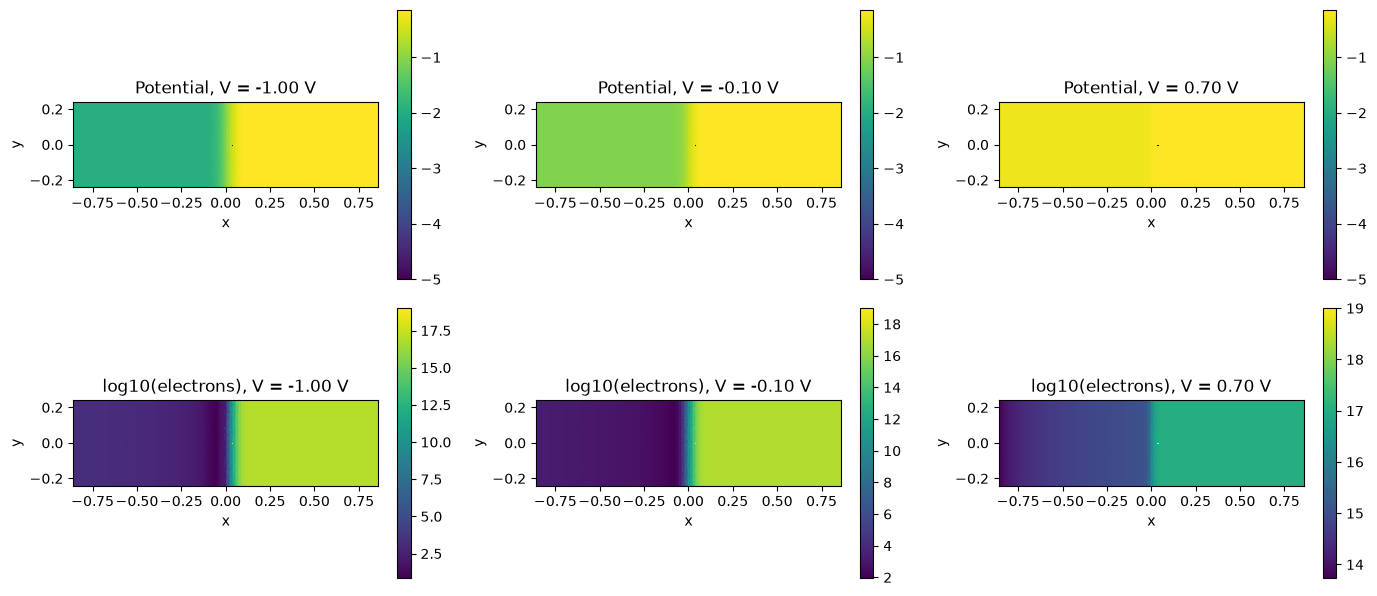

In [17]:
example_voltages = [bias_voltages[0], bias_voltages[len(bias_voltages) // 2], bias_voltages[-1]]

# Resample onto a plain rectangular grid, pulled in slightly from the monitor's
# nominal edges so the query never lands right on (or past) the true edge of the
# underlying finite-volume mesh, which is where .interp() would otherwise extrapolate.
inset_factor = 0.95
x_grid = np.linspace(-inset_factor * monitor_width / 2, inset_factor * monitor_width / 2, 200)
y_grid = np.linspace(-inset_factor * y_height / 2, inset_factor * y_height / 2, 60)

plt.close("all")
fig, axes = plt.subplots(2, 3, figsize=(14, 6))

for col, v in enumerate(example_voltages):
    # method="nearest" on voltage: the stored voltage coordinate may not exactly
    # match the float64 value from bias_voltages after a round trip through storage.
    # TriangularGridDataset.interp() requires x, y and z together, even though the
    # data is invariant along z (the slice's normal direction) - z=0 matches the slice.
    # fill_value=0 pins any remaining out-of-bounds point to 0 instead of extrapolating,
    # since a stray extrapolated outlier otherwise dominates the whole color scale.
    #
    # clip() below is a separate safety net: on rare occasions the (beta) Charge
    # solver's unstructured mesh has a single vertex with a corrupted value. One bad
    # point among thousands is invisible in the data but wrecks the color scale, so
    # values are clamped to a physically reasonable range before plotting.
    potential_grid = (
        charge_data["potential"].potential.sel(voltage=v, z=0, method="nearest")
        .interp(x=x_grid, y=y_grid, z=0, fill_value=0)
        .squeeze()
        .clip(min=-5, max=5)
    )
    potential_grid.plot(ax=axes[0][col], x="x", y="y")
    axes[0][col].set_title(f"Potential, V = {v:.2f} V")
    axes[0][col].set_aspect("equal")

    electrons_grid = (
        charge_data["carriers"].electrons.sel(voltage=v, z=0, method="nearest")
        .interp(x=x_grid, y=y_grid, z=0, fill_value=0)
        .squeeze()
        .clip(min=1e-3, max=1e19)
    )
    np.log10(electrons_grid).plot(ax=axes[1][col], x="x", y="y")
    axes[1][col].set_title(f"log10(electrons), V = {v:.2f} V")
    axes[1][col].set_aspect("equal")

plt.tight_layout()
fig.savefig("data/potential_carriers.png", dpi=150)
plt.show()

### Animation: watch the charge move as voltage sweeps

The plots above only freeze three moments. Here's the full picture: an animation of the net space-charge density across all 18 voltages in the sweep.

$$\rho(x, y) = q \left[ (N_d - N_a) + (p - n) \right]$$

Away from the junction, in ordinary neutral silicon, the mobile carriers cancel the fixed dopant charge almost perfectly, so $\rho \approx 0$ — that's why most of the frame stays blank. The only place charge shows up at all is the depletion region right at the junction. So what you're really watching is that region breathing: narrowing as forward bias grows, widening as reverse bias grows.

One detail: doping itself isn't something the monitors record, so `N_d - N_a` is rebuilt here from the geometry we already know — acceptors for x<0, donors for x>0 — the same trick used in the doping plot near the top of the notebook.

In [25]:
import xarray as xr
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Space charge in the depletion region is bounded by the doping level; this margin
# keeps the color scale fixed and comparable across all frames of the animation.
charge_vmax = 1.5 * doping_concentration


def net_charge_density(v):
    holes_grid = (
        charge_data["carriers"].holes.sel(voltage=v, z=0, method="nearest")
        .interp(x=x_grid, y=y_grid, z=0, fill_value=0)
        .squeeze()
    )
    electrons_grid = (
        charge_data["carriers"].electrons.sel(voltage=v, z=0, method="nearest")
        .interp(x=x_grid, y=y_grid, z=0, fill_value=0)
        .squeeze()
    )
    # Doping isn't a monitor output, so it's rebuilt from the known geometry: acceptors
    # for x < 0, donors for x >= 0. Broadcasts over y automatically via xarray.
    net_doping = xr.where(holes_grid.x < 0, -doping_concentration, doping_concentration)
    rho = (net_doping + holes_grid - electrons_grid).clip(min=-charge_vmax, max=charge_vmax)
    return rho.transpose("y", "x").values


fig, ax = plt.subplots(figsize=(7, 3.5))
mesh = ax.pcolormesh(
    x_grid,
    y_grid,
    net_charge_density(bias_voltages[0]),
    cmap="RdBu_r",
    vmin=-charge_vmax,
    vmax=charge_vmax,
    shading="auto",
)
fig.colorbar(mesh, ax=ax, label="Net charge density (cm$^{-3}$)")
ax.set_xlabel("x (µm)")
ax.set_ylabel("y (µm)")
ax.set_aspect("equal")
title = ax.set_title(f"Net space charge, V = {bias_voltages[0]:.2f} V")


def update(frame):
    v = bias_voltages[frame]
    mesh.set_array(net_charge_density(v).ravel())
    title.set_text(f"Net space charge, V = {v:.2f} V")
    return mesh, title


anim = FuncAnimation(fig, update, frames=len(bias_voltages), interval=400, blit=False)
plt.close(fig)
HTML(anim.to_jshtml())